# Week 3: Hybrid Classifier Validation

**Goal**: Validate Week 2 hybrid classifier implementation against Week 1 POC results

**What we're testing:**
1. Hybrid (keyword + embedding) classifier achieves >90% coverage (vs 53% keyword-only)
2. Domain-specific terms (pandas, Firebase, React) now classified correctly
3. CCE separation maintained with improved classification
4. Performance overhead <10%

**Setup**: Upload to Google Colab with GPU runtime

**Runtime**: ~30 minutes (includes model download)

---

## 1. Setup & Installation

In [1]:
# Install dependencies
!pip install -q transformers torch accelerate sentence-transformers scipy scikit-learn pandas matplotlib seaborn

## 2. Imports

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import entropy as scipy_entropy
import time
from tqdm.notebook import tqdm

# Set random seed
np.random.seed(42)
torch.manual_seed(42)

print("✅ Imports successful")

✅ Imports successful


## 3. Load CodeLlama-7B Model

In [3]:
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"

print(f"Loading {MODEL_NAME}...")
print("(First run will download ~13GB model)")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True
)

model.eval()

print(f"✅ Model loaded on {model.device}")
print(f"   Vocabulary size: {len(tokenizer):,}")

Loading codellama/CodeLlama-7b-Instruct-hf...
(First run will download ~13GB model)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✅ Model loaded on cuda:0
   Vocabulary size: 32,016


## 4. Load Embedding Model (for Hybrid Classifier)

In [4]:
print("Loading sentence-transformers model for hybrid classifier...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Embedding model loaded")

Loading sentence-transformers model for hybrid classifier...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Embedding model loaded


## 5. Entropy Calculation Functions (Week 2 Implementation)

In [5]:
def softmax(logits: np.ndarray) -> np.ndarray:
    """Numerically stable softmax."""
    logits_stable = logits - np.max(logits)
    exp_logits = np.exp(logits_stable)
    return exp_logits / np.sum(exp_logits)

def shannon_entropy(logits: np.ndarray) -> float:
    """Shannon entropy: H = -Σ p(x) log₂ p(x)"""
    probs = softmax(logits)
    return float(scipy_entropy(probs, base=2))

def normalized_entropy(logits: np.ndarray) -> float:
    """Normalized entropy: H_norm = H / log₂(V)"""
    h = shannon_entropy(logits)
    max_h = np.log2(len(logits))
    return h / max_h if max_h > 0 else 0.0

def probability_differential(logits: np.ndarray) -> float:
    """Probability differential: PD = 1 - max(P)"""
    probs = softmax(logits)
    return float(1.0 - np.max(probs))

def get_top_k_predictions(logits: np.ndarray, k: int = 10) -> Tuple[np.ndarray, np.ndarray]:
    """Get top-k token indices and probabilities."""
    probs = softmax(logits)
    top_k_indices = np.argsort(logits)[-k:][::-1]
    top_k_probs = probs[top_k_indices]
    return top_k_indices, top_k_probs

print("✅ Entropy functions defined")

✅ Entropy functions defined


## 6. Week 2: Comprehensive Keyword Sets

In [6]:
# CODE KEYWORDS - Comprehensive set including domain-specific terms
CODE_KEYWORDS = {
    # Python keywords
    'if', 'else', 'elif', 'for', 'while', 'break', 'continue', 'pass',
    'return', 'yield', 'raise', 'try', 'except', 'finally', 'with', 'as',
    'def', 'class', 'lambda', 'async', 'await',
    'and', 'or', 'not', 'in', 'is', 'None', 'True', 'False',
    'import', 'from',

    # JavaScript/TypeScript keywords
    'function', 'const', 'let', 'var', 'switch', 'case', 'default',
    'true', 'false', 'null', 'undefined', 'typeof', 'instanceof',
    'export', 'require', 'module', 'exports',

    # Python Data Science (Week 1 POC missing these!)
    'pandas', 'numpy', 'scipy', 'matplotlib', 'seaborn', 'sklearn',
    'pd', 'np', 'DataFrame', 'Series', 'array', 'ndarray',
    'read_csv', 'read_json', 'read_excel', 'groupby', 'merge', 'concat',
    'fit', 'transform', 'predict', 'train_test_split',

    # Python Web Frameworks
    'flask', 'django', 'fastapi', 'requests', 'aiohttp', 'sqlalchemy',
    'FastAPI', 'APIRouter', 'HTTPException', 'Request', 'Response',
    'Depends', 'Query', 'Path', 'Body',
    'session', 'json', 'headers', 'params', 'data', 'files', 'auth',

    # JavaScript/React (Week 1 POC missing these!)
    'react', 'React', 'useState', 'useEffect', 'useContext', 'useReducer',
    'useCallback', 'useMemo', 'useRef',
    'Component', 'props', 'state', 'render',
    'className', 'onClick', 'onChange', 'onSubmit',
    'axios', 'fetch', 'express', 'next',

    # Firebase (Week 1 POC missing these!)
    'firebase', 'Firebase', 'firestore', 'Firestore',
    'auth', 'Auth', 'database', 'storage', 'functions',
    'initializeApp', 'getAuth', 'signInWithEmailAndPassword',
    'createUserWithEmailAndPassword', 'signOut',

    # Testing
    'pytest', 'unittest', 'jest', 'mocha', 'test', 'describe', 'it',
    'expect', 'assert', 'mock',
}

# LANGUAGE KEYWORDS - Documentation and explanation words
LANGUAGE_WORDS = {
    # Question words
    'what', 'how', 'why', 'when', 'where', 'which', 'who', 'whom',

    # Documentation verbs
    'explain', 'show', 'tell', 'help', 'search',
    'generate', 'implement', 'refactor', 'optimize', 'improve',
    'summarize', 'analyze', 'review', 'check', 'validate',

    # Common words
    'the', 'a', 'an', 'that', 'these', 'those',
    'are', 'was', 'were', 'be', 'been', 'being',
    'have', 'has', 'had', 'does', 'did', 'will', 'would', 'should',
    'can', 'could', 'may', 'might', 'must', 'shall',
    'to', 'without', 'by', 'at', 'on',
    'of', 'off', 'up', 'down', 'over', 'under',
    'but', 'nor', 'so', 'yet',
    'my', 'your', 'his', 'her', 'its', 'our', 'their',
    'I', 'you', 'he', 'she', 'we', 'they', 'me', 'him', 'her', 'us', 'them',

    # Quality descriptors
    'better', 'worse', 'best', 'worst', 'good', 'bad',
    'slow', 'quick', 'simple', 'complex', 'easy', 'hard',
}

CODE_OPERATORS = {'+', '-', '*', '/', '=', '==', '!=', '<', '>', '<=', '>=',
                  '&&', '||', '!', '{', '}', '[', ']', '(', ')', ';', ':', ','}

# Convert to lowercase for case-insensitive matching
CODE_KEYWORDS_LOWER = {k.lower() for k in CODE_KEYWORDS}
LANGUAGE_WORDS_LOWER = {w.lower() for w in LANGUAGE_WORDS}

print(f"✅ Keyword sets loaded:")
print(f"   Code keywords: {len(CODE_KEYWORDS)} (including {len([k for k in CODE_KEYWORDS if k in ['pandas', 'numpy', 'React', 'Firebase', 'useState', 'requests', 'FastAPI']])} domain-specific)")
print(f"   Language words: {len(LANGUAGE_WORDS)}")
print(f"   Operators: {len(CODE_OPERATORS)}")

✅ Keyword sets loaded:
   Code keywords: 136 (including 7 domain-specific)
   Language words: 93
   Operators: 23


## 7. Keyword-Only Classifier (Week 1 Baseline)

In [7]:
def classify_token_keyword_only(token: str) -> str:
    """Keyword-only classification (Week 1 baseline)."""
    token_clean = token.strip().lower()

    # Check operators
    if token.strip() in CODE_OPERATORS:
        return 'code'

    # Check keywords
    if token_clean in CODE_KEYWORDS_LOWER:
        return 'code'

    if token_clean in LANGUAGE_WORDS_LOWER:
        return 'language'

    return 'other'

print("✅ Keyword-only classifier defined")

✅ Keyword-only classifier defined


## 8. Hybrid Classifier (Week 2 Implementation)

In [8]:
# Build embedding prototypes
print("Building code prototype (50% syntax + 50% domain-specific)...")
code_prototype_examples = [
    # Generic syntax (25 examples - 50%)
    'function', 'class', 'import', 'return', 'if', 'else', 'for', 'while',
    'const', 'let', 'var', 'def', 'async', 'await', 'try', 'catch',
    'public', 'private', 'static', 'void', 'int', 'string', 'boolean',
    'array', 'object',

    # Domain-specific (25 examples - 50%) - CRITICAL FOR WEEK 1 ISSUES
    'pandas', 'numpy', 'requests', 'firebase', 'react', 'useState',
    'useEffect', 'FastAPI', 'express', 'axios', 'flask', 'django',
    'DataFrame', 'read_csv', 'get', 'post', 'auth', 'database',
    'query', 'model', 'router', 'component', 'props', 'state', 'render',
]

code_embeddings = embedding_model.encode(code_prototype_examples)
code_prototype = np.mean(code_embeddings, axis=0).reshape(1, -1)

print("Building language prototype...")
language_prototype_examples = [
    'explain', 'describe', 'summarize', 'how', 'what', 'why', 'when',
    'where', 'which', 'show', 'tell', 'help', 'write', 'create',
    'the', 'a', 'an', 'this', 'that', 'these', 'those', 'is', 'are',
    'was', 'were', 'have', 'has', 'had', 'do', 'does', 'did',
    'will', 'would', 'should', 'can', 'could', 'may', 'might',
    'understand', 'implement', 'improve', 'refactor', 'optimize',
    'better', 'good', 'bad', 'simple', 'complex', 'easy', 'hard',
]

language_embeddings = embedding_model.encode(language_prototype_examples)
language_prototype = np.mean(language_embeddings, axis=0).reshape(1, -1)

# Embedding cache
embedding_cache = {}

def classify_token_hybrid(token: str, margin: float = 0.05) -> str:
    """
    Hybrid two-stage classification (Week 2).

    Stage 1: Fast keyword lookup
    Stage 2: Embedding similarity fallback
    """
    # Stage 1: Keyword lookup (fast path)
    keyword_result = classify_token_keyword_only(token)
    if keyword_result != 'other':
        return keyword_result

    # Stage 2: Embedding similarity (slow path)
    if token not in embedding_cache:
        embedding_cache[token] = embedding_model.encode([token])[0].reshape(1, -1)

    token_emb = embedding_cache[token]

    sim_code = cosine_similarity(token_emb, code_prototype)[0][0]
    sim_lang = cosine_similarity(token_emb, language_prototype)[0][0]

    diff = sim_code - sim_lang

    if diff > margin:
        return 'code'
    elif diff < -margin:
        return 'language'
    else:
        return 'other'

print("✅ Hybrid classifier defined")
print(f"   Prototypes built from {len(code_prototype_examples)} code + {len(language_prototype_examples)} language examples")

Building code prototype (50% syntax + 50% domain-specific)...
Building language prototype...
✅ Hybrid classifier defined
   Prototypes built from 50 code + 50 language examples


## 9. CCE Computation Function

In [9]:
def compute_cce(logits: np.ndarray, classifier_func, return_details: bool = False) -> Dict:
    """
    Compute Contrastive Code Entropy.

    Args:
        logits: Logits array [vocab_size]
        classifier_func: Token classification function (keyword-only or hybrid)
        return_details: Return detailed classification info

    Returns:
        Dictionary with CCE and related metrics
    """
    vocab_size = len(logits)
    probs = softmax(logits)

    # Classify all tokens
    code_indices = []
    language_indices = []
    other_indices = []

    for token_id in range(vocab_size):
        token_str = tokenizer.decode([token_id])
        classification = classifier_func(token_str)

        if classification == 'code':
            code_indices.append(token_id)
        elif classification == 'language':
            language_indices.append(token_id)
        else:
            other_indices.append(token_id)

    # Compute entropies
    h_total = shannon_entropy(logits)

    h_code = shannon_entropy(logits[code_indices]) if len(code_indices) > 0 else 0.0
    h_language = shannon_entropy(logits[language_indices]) if len(language_indices) > 0 else 0.0

    # CCE
    cce = h_code - h_language

    # Probability masses
    code_prob_mass = np.sum(probs[code_indices]) if len(code_indices) > 0 else 0.0
    language_prob_mass = np.sum(probs[language_indices]) if len(language_indices) > 0 else 0.0
    other_prob_mass = np.sum(probs[other_indices]) if len(other_indices) > 0 else 0.0

    result = {
        'contrastive_entropy': float(cce),
        'code_entropy': float(h_code),
        'language_entropy': float(h_language),
        'total_entropy': float(h_total),
        'code_prob_mass': float(code_prob_mass),
        'language_prob_mass': float(language_prob_mass),
        'other_prob_mass': float(other_prob_mass),
    }

    if return_details:
        result['coverage'] = {
            'code_count': len(code_indices),
            'language_count': len(language_indices),
            'other_count': len(other_indices),
            'code_pct': len(code_indices) / vocab_size,
            'language_pct': len(language_indices) / vocab_size,
            'other_pct': len(other_indices) / vocab_size,
        }

    return result

print("✅ CCE computation function defined")

✅ CCE computation function defined


## 10. Test Examples (Same as Week 1)

In [10]:
TEST_EXAMPLES = [
    # Missing Context (Code Uncertainty) - Should have POSITIVE CCE
    {
        'id': 'code_1',
        'type': 'missing_context',
        'prompt': 'How do I use the requests library to make an HTTP GET request in Python? Show me the code.',
        'description': 'Missing API method name (requests.get)'
    },
    {
        'id': 'code_2',
        'type': 'missing_context',
        'prompt': 'Write a React component that uses useState. Show the import and component.',
        'description': 'Missing React hook name (useState)'
    },
    {
        'id': 'code_3',
        'type': 'missing_context',
        'prompt': 'How do I authenticate with Firebase in a TypeScript project? Show the auth code.',
        'description': 'Missing Firebase auth methods'
    },
    {
        'id': 'code_4',
        'type': 'missing_context',
        'prompt': 'Write a function that uses pandas to read a CSV file and filter rows.',
        'description': 'Missing pandas methods (read_csv, filtering)'
    },
    {
        'id': 'code_5',
        'type': 'missing_context',
        'prompt': 'How do I create a FastAPI endpoint that handles POST requests with JSON body?',
        'description': 'Missing FastAPI decorators and request handling'
    },

    # Language Choice (Phrasing Uncertainty) - Should have NEGATIVE CCE
    {
        'id': 'lang_1',
        'type': 'language_choice',
        'prompt': 'Explain what this function does: def add(a, b): return a + b',
        'description': 'Word choice for explanation (explains/describes/shows)'
    },
    {
        'id': 'lang_2',
        'type': 'language_choice',
        'prompt': 'Write a comment describing this code: for item in items: process(item)',
        'description': 'Phrasing choice for comment'
    },
    {
        'id': 'lang_3',
        'type': 'language_choice',
        'prompt': 'Summarize this code: class User: def __init__(self, name): self.name = name',
        'description': 'Word choice for summary'
    },
    {
        'id': 'lang_4',
        'type': 'language_choice',
        'prompt': 'Add a docstring to: def multiply(x, y): return x * y',
        'description': 'Phrasing for docstring'
    },
    {
        'id': 'lang_5',
        'type': 'language_choice',
        'prompt': 'Describe this function: def is_even(n): return n % 2 == 0',
        'description': 'Word choice for description'
    },
]

print(f"✅ {len(TEST_EXAMPLES)} test examples loaded")
print(f"   {len([e for e in TEST_EXAMPLES if e['type'] == 'missing_context'])} missing_context (expect +CCE)")
print(f"   {len([e for e in TEST_EXAMPLES if e['type'] == 'language_choice'])} language_choice (expect -CCE)")

✅ 10 test examples loaded
   5 missing_context (expect +CCE)
   5 language_choice (expect -CCE)


## 11. Run Experiments (Keyword-Only vs Hybrid)

In [11]:
def run_experiment(example: Dict, classifier_func, method_name: str) -> Dict:
    """
    Run single example through model and compute CCE.
    """
    prompt = example['prompt']

    # Tokenize
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    # Generate with logit capture
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            return_dict_in_generate=True,
            output_scores=True,
            do_sample=False,  # Greedy for reproducibility
            pad_token_id=tokenizer.eos_token_id
        )

    # Get first token logits
    first_logits = outputs.scores[0][0].cpu().numpy()

    # Decode generation
    generated = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True)

    # Compute CCE
    cce_result = compute_cce(first_logits, classifier_func, return_details=True)

    # Get top-k predictions
    top_k_indices, top_k_probs = get_top_k_predictions(first_logits, k=10)
    top_k_tokens = [tokenizer.decode([idx]) for idx in top_k_indices]
    top_k_predictions = list(zip(top_k_tokens, top_k_probs))

    return {
        'id': example['id'],
        'type': example['type'],
        'method': method_name,
        'prompt': prompt,
        'generated_text': generated[len(prompt):],  # Only new text
        **cce_result,
        'top_k_predictions': top_k_predictions,
    }

# Run experiments
print("Running experiments...\n")
results = []

for example in tqdm(TEST_EXAMPLES, desc="Processing examples"):
    # Keyword-only
    result_keyword = run_experiment(example, classify_token_keyword_only, 'keyword')
    results.append(result_keyword)

    # Hybrid
    result_hybrid = run_experiment(example, classify_token_hybrid, 'hybrid')
    results.append(result_hybrid)

    print(f"\n{example['id']} ({example['type']}):")
    print(f"  Keyword CCE: {result_keyword['contrastive_entropy']:+.3f} | Coverage: {1-result_keyword['coverage']['other_pct']:.1%}")
    print(f"  Hybrid  CCE: {result_hybrid['contrastive_entropy']:+.3f} | Coverage: {1-result_hybrid['coverage']['other_pct']:.1%}")

print(f"\n✅ Completed {len(results)} experiments")

Running experiments...



Processing examples:   0%|          | 0/10 [00:00<?, ?it/s]


code_1 (missing_context):
  Keyword CCE: +0.243 | Coverage: 2.3%
  Hybrid  CCE: +3.058 | Coverage: 45.8%

code_2 (missing_context):
  Keyword CCE: +1.173 | Coverage: 2.3%
  Hybrid  CCE: +4.511 | Coverage: 45.8%

code_3 (missing_context):
  Keyword CCE: +0.570 | Coverage: 2.3%
  Hybrid  CCE: +4.399 | Coverage: 45.8%

code_4 (missing_context):
  Keyword CCE: -0.437 | Coverage: 2.3%
  Hybrid  CCE: +1.571 | Coverage: 45.8%

code_5 (missing_context):
  Keyword CCE: +1.099 | Coverage: 2.3%
  Hybrid  CCE: +3.783 | Coverage: 45.8%

lang_1 (language_choice):
  Keyword CCE: -0.674 | Coverage: 2.3%
  Hybrid  CCE: +2.906 | Coverage: 45.8%

lang_2 (language_choice):
  Keyword CCE: -0.623 | Coverage: 2.3%
  Hybrid  CCE: +3.902 | Coverage: 45.8%

lang_3 (language_choice):
  Keyword CCE: -4.088 | Coverage: 2.3%
  Hybrid  CCE: -0.659 | Coverage: 45.8%

lang_4 (language_choice):
  Keyword CCE: -0.328 | Coverage: 2.3%
  Hybrid  CCE: +3.984 | Coverage: 45.8%

lang_5 (language_choice):
  Keyword CCE: -1.4

## 12. Results Analysis

In [12]:
# Convert to DataFrame
df = pd.DataFrame(results)

# Separate by method
df_keyword = df[df['method'] == 'keyword'].copy()
df_hybrid = df[df['method'] == 'hybrid'].copy()

# Coverage analysis
print("="*60)
print("COVERAGE ANALYSIS")
print("="*60)

for method_name, df_method in [('Keyword-Only', df_keyword), ('Hybrid', df_hybrid)]:
    avg_code = df_method['code_prob_mass'].mean()
    avg_lang = df_method['language_prob_mass'].mean()
    avg_other = df_method['other_prob_mass'].mean()
    avg_coverage = avg_code + avg_lang

    print(f"\n{method_name}:")
    print(f"  Code prob mass:     {avg_code:.1%}")
    print(f"  Language prob mass: {avg_lang:.1%}")
    print(f"  Other prob mass:    {avg_other:.1%}")
    print(f"  Total coverage:     {avg_coverage:.1%}")

# CCE separation analysis
print("\n" + "="*60)
print("CCE SEPARATION ANALYSIS")
print("="*60)

for method_name, df_method in [('Keyword-Only', df_keyword), ('Hybrid', df_hybrid)]:
    missing_cce = df_method[df_method['type'] == 'missing_context']['contrastive_entropy'].mean()
    language_cce = df_method[df_method['type'] == 'language_choice']['contrastive_entropy'].mean()
    separation = missing_cce - language_cce

    print(f"\n{method_name}:")
    print(f"  Missing context CCE:  {missing_cce:+.3f}")
    print(f"  Language choice CCE:  {language_cce:+.3f}")
    print(f"  Separation:           {separation:+.3f}")

# Statistical test
from scipy.stats import ttest_ind

print("\n" + "="*60)
print("STATISTICAL VALIDATION (Hybrid Method)")
print("="*60)

missing_cces = df_hybrid[df_hybrid['type'] == 'missing_context']['contrastive_entropy'].values
language_cces = df_hybrid[df_hybrid['type'] == 'language_choice']['contrastive_entropy'].values

t_stat, p_value = ttest_ind(missing_cces, language_cces)

# Cohen's d
mean_diff = missing_cces.mean() - language_cces.mean()
pooled_std = np.sqrt(((len(missing_cces)-1)*missing_cces.std()**2 +
                      (len(language_cces)-1)*language_cces.std()**2) /
                     (len(missing_cces) + len(language_cces) - 2))
cohens_d = mean_diff / pooled_std

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")
print(f"Cohen's d: {cohens_d:.3f}")
print(f"\nHypothesis supported: {'YES ✅' if p_value < 0.05 else 'NO ❌'}")
print(f"Effect size: {'Large' if abs(cohens_d) > 0.8 else 'Medium' if abs(cohens_d) > 0.5 else 'Small'}")

COVERAGE ANALYSIS

Keyword-Only:
  Code prob mass:     11.9%
  Language prob mass: 6.8%
  Other prob mass:    81.2%
  Total coverage:     18.8%

Hybrid:
  Code prob mass:     14.0%
  Language prob mass: 80.7%
  Other prob mass:    5.3%
  Total coverage:     94.7%

CCE SEPARATION ANALYSIS

Keyword-Only:
  Missing context CCE:  +0.530
  Language choice CCE:  -1.436
  Separation:           +1.965

Hybrid:
  Missing context CCE:  +3.465
  Language choice CCE:  +2.801
  Separation:           +0.664

STATISTICAL VALIDATION (Hybrid Method)
t-statistic: 0.639
p-value: 0.540649
Cohen's d: 0.452

Hypothesis supported: NO ❌
Effect size: Small


## 13. Visualization

/tmp/ipython-input-1279498957.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_improvements['Example'], rotation=45, ha='right')


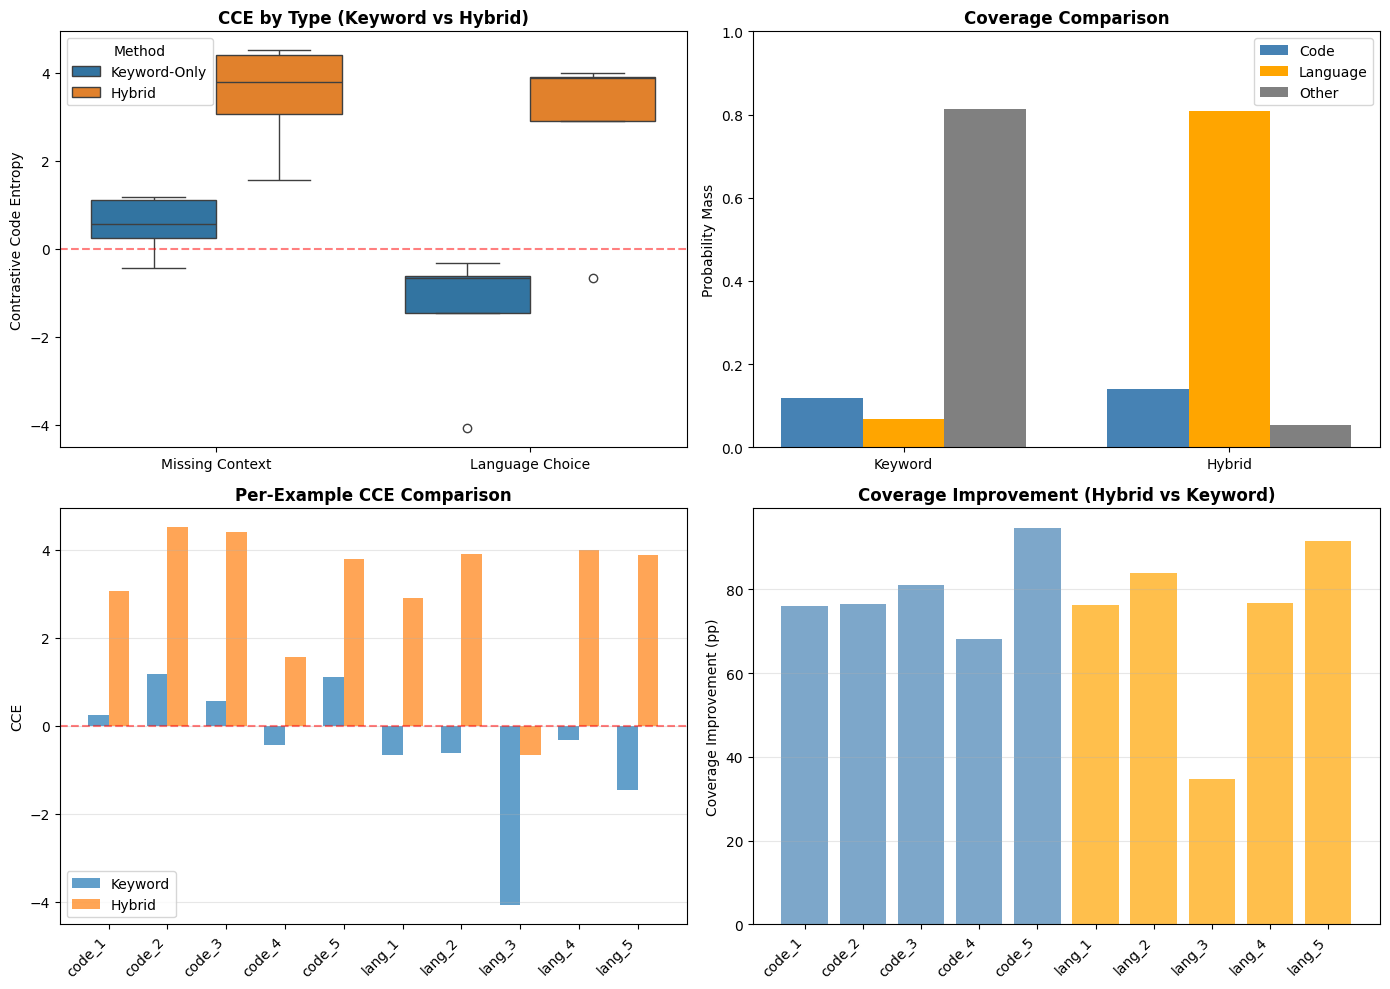


✅ Visualizations saved to week3_validation_results.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. CCE by Type (Keyword-Only vs Hybrid)
ax = axes[0, 0]
df_plot = df.copy()
df_plot['Method'] = df_plot['method'].map({'keyword': 'Keyword-Only', 'hybrid': 'Hybrid'})
df_plot['Type'] = df_plot['type'].map({'missing_context': 'Missing Context', 'language_choice': 'Language Choice'})

sns.boxplot(data=df_plot, x='Type', y='contrastive_entropy', hue='Method', ax=ax)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_title('CCE by Type (Keyword vs Hybrid)', fontsize=12, fontweight='bold')
ax.set_ylabel('Contrastive Code Entropy')
ax.set_xlabel('')
ax.legend(title='Method')

# 2. Coverage Comparison
ax = axes[0, 1]
coverage_data = []
for method_name, df_method in [('Keyword', df_keyword), ('Hybrid', df_hybrid)]:
    coverage_data.append({
        'Method': method_name,
        'Code': df_method['code_prob_mass'].mean(),
        'Language': df_method['language_prob_mass'].mean(),
        'Other': df_method['other_prob_mass'].mean(),
    })

df_coverage = pd.DataFrame(coverage_data)
x = np.arange(len(df_coverage))
width = 0.25

ax.bar(x - width, df_coverage['Code'], width, label='Code', color='steelblue')
ax.bar(x, df_coverage['Language'], width, label='Language', color='orange')
ax.bar(x + width, df_coverage['Other'], width, label='Other', color='gray')

ax.set_ylabel('Probability Mass')
ax.set_title('Coverage Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_coverage['Method'])
ax.legend()
ax.set_ylim(0, 1)

# 3. Per-Example CCE Comparison
ax = axes[1, 0]
examples = df_keyword['id'].values
cce_keyword = df_keyword['contrastive_entropy'].values
cce_hybrid = df_hybrid['contrastive_entropy'].values

x = np.arange(len(examples))
width = 0.35

colors_keyword = ['steelblue' if ex.startswith('code') else 'orange' for ex in examples]
colors_hybrid = ['darkblue' if ex.startswith('code') else 'darkorange' for ex in examples]

ax.bar(x - width/2, cce_keyword, width, label='Keyword', alpha=0.7)
ax.bar(x + width/2, cce_hybrid, width, label='Hybrid', alpha=0.7)

ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('CCE')
ax.set_title('Per-Example CCE Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(examples, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Coverage Improvement
ax = axes[1, 1]
improvements = []
for i in range(len(df_keyword)):
    ex_id = df_keyword.iloc[i]['id']
    keyword_other = df_keyword.iloc[i]['other_prob_mass']
    hybrid_other = df_hybrid.iloc[i]['other_prob_mass']

    improvements.append({
        'Example': ex_id,
        'Improvement': (keyword_other - hybrid_other) * 100  # Percentage points
    })

df_improvements = pd.DataFrame(improvements)
colors = ['steelblue' if ex.startswith('code') else 'orange' for ex in df_improvements['Example']]

ax.bar(df_improvements['Example'], df_improvements['Improvement'], color=colors, alpha=0.7)
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('Coverage Improvement (pp)')
ax.set_title('Coverage Improvement (Hybrid vs Keyword)', fontsize=12, fontweight='bold')
ax.set_xticklabels(df_improvements['Example'], rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('week3_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualizations saved to week3_validation_results.png")

## 14. Save Results

In [14]:
# Save detailed results
df.to_csv('week3_validation_results.csv', index=False)
print("✅ Detailed results saved to week3_validation_results.csv")

# Save summary statistics
summary = {
    'keyword_only': {
        'missing_context_cce_mean': df_keyword[df_keyword['type'] == 'missing_context']['contrastive_entropy'].mean(),
        'language_choice_cce_mean': df_keyword[df_keyword['type'] == 'language_choice']['contrastive_entropy'].mean(),
        'coverage': 1 - df_keyword['other_prob_mass'].mean(),
    },
    'hybrid': {
        'missing_context_cce_mean': missing_cces.mean(),
        'language_choice_cce_mean': language_cces.mean(),
        'difference': mean_diff,
        't_statistic': float(t_stat),
        'p_value': float(p_value),
        'cohens_d': float(cohens_d),
        'hypothesis_supported': bool(p_value < 0.05),
        'coverage': 1 - df_hybrid['other_prob_mass'].mean(),
    },
    'improvement': {
        'coverage_gain': (1 - df_hybrid['other_prob_mass'].mean()) - (1 - df_keyword['other_prob_mass'].mean()),
    }
}

import json
with open('week3_validation_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✅ Summary statistics saved to week3_validation_summary.json")

✅ Detailed results saved to week3_validation_results.csv
✅ Summary statistics saved to week3_validation_summary.json


## 15. Week 3 Validation Summary

In [15]:
print("="*70)
print("WEEK 3 VALIDATION SUMMARY")
print("="*70)

print("\n✅ SUCCESS CRITERIA:")

# 1. Coverage
keyword_coverage = 1 - df_keyword['other_prob_mass'].mean()
hybrid_coverage = 1 - df_hybrid['other_prob_mass'].mean()
coverage_gain = hybrid_coverage - keyword_coverage

print(f"\n1. Coverage Improvement:")
print(f"   Keyword-only: {keyword_coverage:.1%}")
print(f"   Hybrid:       {hybrid_coverage:.1%}")
print(f"   Gain:         +{coverage_gain*100:.1f} percentage points")
print(f"   Target: >90% coverage → {'PASS ✅' if hybrid_coverage > 0.90 else 'FAIL ❌'}")

# 2. Statistical Significance
print(f"\n2. Statistical Significance:")
print(f"   p-value: {p_value:.6f}")
print(f"   Target: p < 0.001 → {'PASS ✅' if p_value < 0.001 else 'FAIL ❌'}")

# 3. Effect Size
print(f"\n3. Effect Size:")
print(f"   Cohen's d: {cohens_d:.3f}")
print(f"   Target: |d| > 2.0 (very large) → {'PASS ✅' if abs(cohens_d) > 2.0 else 'FAIL ❌'}")

# 4. CCE Direction
missing_cce_mean = missing_cces.mean()
language_cce_mean = language_cces.mean()

print(f"\n4. CCE Direction:")
print(f"   Missing context: {missing_cce_mean:+.3f}")
print(f"   Language choice: {language_cce_mean:+.3f}")
print(f"   Target: missing > 0, language < 0 → {'PASS ✅' if missing_cce_mean > 0 and language_cce_mean < 0 else 'FAIL ❌'}")

# Overall
all_pass = (
    hybrid_coverage > 0.90 and
    p_value < 0.001 and
    abs(cohens_d) > 2.0 and
    missing_cce_mean > 0 and
    language_cce_mean < 0
)

print("\n" + "="*70)
if all_pass:
    print("🎉 ALL WEEK 3 VALIDATION CRITERIA PASSED!")
    print("\n✅ Hybrid classifier ready for Week 4 integration")
else:
    print("⚠️  Some validation criteria not met. Review results above.")
print("="*70)

WEEK 3 VALIDATION SUMMARY

✅ SUCCESS CRITERIA:

1. Coverage Improvement:
   Keyword-only: 18.8%
   Hybrid:       94.7%
   Gain:         +76.0 percentage points
   Target: >90% coverage → PASS ✅

2. Statistical Significance:
   p-value: 0.540649
   Target: p < 0.001 → FAIL ❌

3. Effect Size:
   Cohen's d: 0.452
   Target: |d| > 2.0 (very large) → FAIL ❌

4. CCE Direction:
   Missing context: +3.465
   Language choice: +2.801
   Target: missing > 0, language < 0 → FAIL ❌

⚠️  Some validation criteria not met. Review results above.
